load model code and model weights

In [2]:
FISRT_RUN = globals().get("FISRT_RUN", True)
if FISRT_RUN:
    import os
    os.chdir("..")
    from shared_libs.eec_parse import extend_extra_sys_path
    extend_extra_sys_path("EQNet/EEC.md")
FISRT_RUN = False

In [99]:
import sys
sys.path

['/home/hyuyao/2024/trackpred_v2/EQNet',
 '/home/hyuyao/2024/trackpred_v2/EQNet',
 '/home/hyuyao/miniconda3/envs/RAMoPred/lib/python311.zip',
 '/home/hyuyao/miniconda3/envs/RAMoPred/lib/python3.11',
 '/home/hyuyao/miniconda3/envs/RAMoPred/lib/python3.11/lib-dynload',
 '',
 '/home/hyuyao/miniconda3/envs/RAMoPred/lib/python3.11/site-packages',
 '__editable__.evalai-1.3.16.finder.__path_hook__',
 '/home/hyuyao/miniconda3/envs/RAMoPred/lib/python3.11/site-packages/conda_minify-0.1.2-py3.8.egg',
 'EQNet',
 'shared_libs/3rd_party',
 'shared_libs/3rd_party/qcnet_55cacb4',
 'shared_libs/3rd_party/fairscale_3e6616',
 'shared_libs/3rd_party/pytorch-image-models_2696ee',
 'shared_libs/3rd_party/torchscale_4d1e0e']

In [100]:
import os
os.path.abspath(".")

'/home/hyuyao/2024/trackpred_v2'

In [101]:
MACHINE = "3090-C"

def get_model(name):

    match name:

        case "EQNet":

            MODEL_WEIGHT = "results/EQNet.RA-L/version_0/checkpoints/epoch=62-step=393624.ckpt"
            
            from eqnet import EQNet

            model = EQNet.load_from_checkpoint(MODEL_WEIGHT)

            out_dir = "EQNet-Viz"

        case "QCNet":

            MODEL_WEIGHT = "shared_libs/3rd_party/qcnet_55cacb4/ckpt/QCNet_AV2.ckpt"

            from qcnet_55cacb4.predictors import QCNet

            model = QCNet.load_from_checkpoint(MODEL_WEIGHT)

            out_dir = "QCNet-Viz"

    return model, out_dir

model, out_dir = get_model("EQNet")

load data range and then call the model to get the prediction results

In [120]:
from EQNet.data import get_argoverse_v2_dataset_for_qcnet

dataset = get_argoverse_v2_dataset_for_qcnet(MACHINE, "val")
raw_file_names = dataset.raw_file_names
data= dataset[raw_file_names.index("12a08897-cf80-4469-9e7e-7851ff85cc60")]
result = model.forward(data.cuda())

In [103]:
from shared_libs.desc import desc
desc({"data":data, "result": result})

{
│   'data': {
│   │   '_global_store': {'scenario_id': bb879669-1341-49d9-8a94-665e59e5ffd4, 'city': austin},
│   │   'agent': {
│   │   │   'num_nodes': 78,
│   │   │   'av_index': 77,
│   │   │   'valid_mask': Tensor((78, 110), bool),
│   │   │   'predict_mask': Tensor((78, 110), bool),
│   │   │   'id': ['169400', ...],
│   │   │   'type': Tensor((78,), uint8),
│   │   │   'category': Tensor((78,), uint8),
│   │   │   'position': Tensor((78, 110, 3), float32),
│   │   │   'heading': Tensor((78, 110), float32),
│   │   │   'velocity': Tensor((78, 110, 3), float32),
│   │   │   'target': Tensor((78, 60, 4), float32)
│   │   },
│   │   'map_polygon': {
│   │   │   'num_nodes': 86,
│   │   │   'position': Tensor((86, 3), float32),
│   │   │   'orientation': Tensor((86,), float32),
│   │   │   'height': Tensor((86,), float32),
│   │   │   'type': Tensor((86,), uint8),
│   │   │   'is_intersection': Tensor((86,), uint8)
│   │   },
│   │   'map_point': {
│   │   │   'num_nodes': 1617,
│   │   │   'position': Tensor((1617, 3), float32),
│   │   │   'orientation': Tensor((1617,), float32),
│   │   │   'magnitude': Tensor((1617,), float32),
│   │   │   'height': Tensor((1617,), float32),
│   │   │   'type': Tensor((1617,), uint8),
│   │   │   'side': Tensor((1617,), uint8)
│   │   },
│   │   ('map_point', 'to', 'map_polygon'): {'edge_index': Tensor((2, 1617), int64)},
│   │   ('map_polygon', 'to', 'map_polygon'): {
│   │   │   'edge_index': Tensor((2, 216), int64),
│   │   │   'type': Tensor((216,), uint8)
│   │   }
│   },
│   'result': {
│   │   'loc_propose_pos': Tensor((78, 6, 60, 2), float32),
│   │   'scale_propose_pos': Tensor((78, 6, 60, 2), float32),
│   │   'loc_propose_head': Tensor((78, 6, 60, 1), float32),
│   │   'conc_propose_head': Tensor((78, 6, 60, 1), float32),
│   │   'loc_refine_pos': Tensor((78, 6, 60, 2), float32),
│   │   'scale_refine_pos': Tensor((78, 6, 60, 2), float32),
│   │   'loc_refine_head': Tensor((78, 6, 60, 1), float32),
│   │   'conc_refine_head': Tensor((78, 6, 60, 1), float32),
│   │   'pi': Tensor((78, 6), float32)
│   }
}

draw the elements

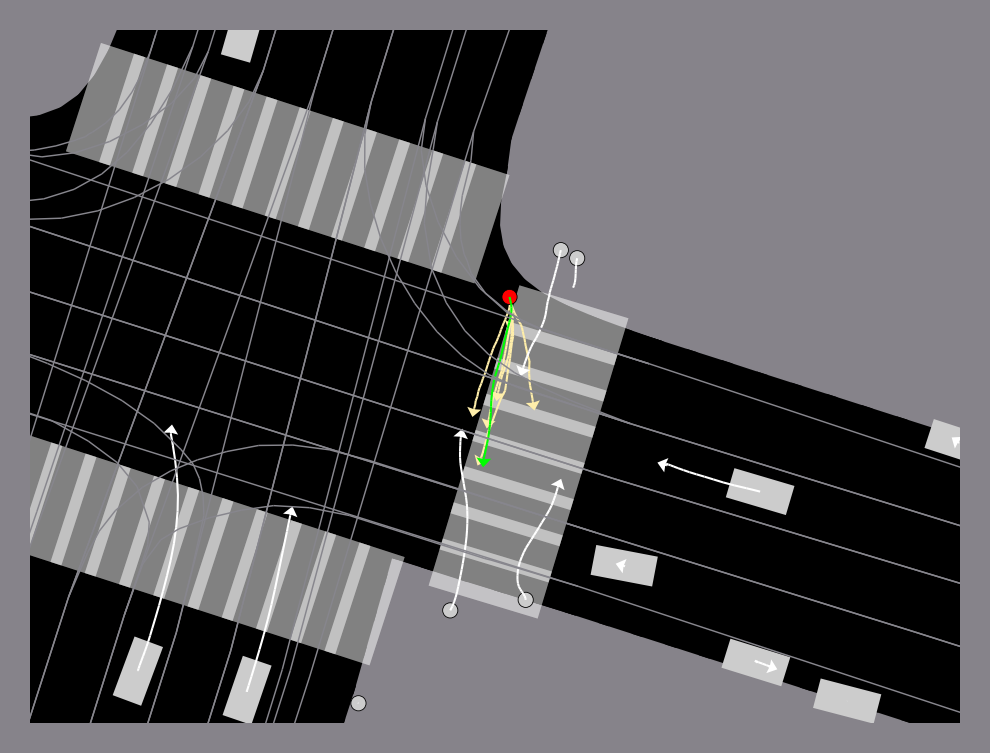

In [141]:
import torch
import matplotlib
from matplotlib.pyplot import subplots, show
from matplotlib.axes import Axes

fd = dict(fontsize=8)

fig, axes = subplots(1, 1, squeeze=False, dpi=300, figsize=(4, 3))
fig.patch.set_facecolor('#86838a')
ax:Axes = axes[0][0]


def draw_scene_qcnet_style():

    agent = data['agent']
    focal_index = agent['category'].tolist().index(3)
    focal_pos = agent['position'][focal_index]
    lfocal = (focal_pos[-1, :2] - focal_pos[50, :2]).norm().item()
    r = 0.025 * lfocal + 1

    # is_pedestrian = (agent['type'][focal_index].item() == 1)

    matplotlib.rcParams['lines.markersize'] = 1.
    # draw map points
    map_point_side = data['map_point']['side'].cpu()
    map_point_plid = data['map_point', 'to', 'map_polygon']['edge_index'][1].cpu()
    map_point_type = data['map_polygon']['type'].cpu()[map_point_plid]
    # print(map_point_type.unique())
    centerline_mask = map_point_side == 2
    crossing_mask = map_point_type == 3
    map_point_position = data['map_point']['position'].cpu()
    map_point_orientation = data['map_point']['orientation'].cpu()
    map_point_magnitude = data['map_point']['magnitude'].cpu()
    
    def draw_lanes(mask, bg, halfw=3, fg="#87868d"):
        # draw bg color
        from matplotlib.collections import PolyCollection, LineCollection
        mag = map_point_magnitude[centerline_mask & mask][:, None]
        ang = map_point_orientation[centerline_mask & mask]
        lon = torch.stack([ang.cos(), ang.sin()], dim=1)
        lat = torch.stack([(ang+torch.pi/2).cos(), (ang+torch.pi/2).sin()], dim=1)
        p0 = map_point_position[centerline_mask & mask][:, :2] - lon * 0.3
        p1 = p0 + halfw * -lat
        p2 = p1 + lon * (mag + 0.6)
        p3 = p2 + 2 * halfw * lat
        p4 = p3 - lon * (mag + 0.6)
        verts = torch.stack([p0, p1, p2, p3, p4], dim=1)
        polys = PolyCollection(verts, color=bg, edgecolor=None, zorder=-100)
        ax.add_collection(polys)
        # draw border lines
        if fg is not None:
            mag = map_point_magnitude[~centerline_mask & mask][:, None]
            ang = map_point_orientation[~centerline_mask & mask]
            lon = torch.stack([ang.cos(), ang.sin()], dim=1)
            p0 = map_point_position[~centerline_mask & mask][:, :2]
            p1 = p0 + lon * mag
            verts = torch.stack([p0, p1], dim=1)
            lines = LineCollection(verts, color=fg, linewidths=0.35, zorder=100)
            ax.add_collection(lines)
        
    draw_lanes(~crossing_mask, bg="k")
    draw_lanes(crossing_mask, bg=(1.,1.,1.,.3), fg=None)
    # ax.scatter(map_point_position[centerline_mask & ~crossing_mask][:, 0],
    #             map_point_position[centerline_mask & ~crossing_mask][:, 1])
    # ax.scatter(map_point_position[centerline_mask & crossing_mask][:, 0],
    #             map_point_position[centerline_mask & crossing_mask][:, 1])
    
    def draw_agents(mask, halfw, length, carcolor='b', pedcolor='red', t=0):
        from matplotlib.collections import PolyCollection, LineCollection
        import matplotlib.pyplot as plt
        valid_mask = data['agent']['valid_mask'].cpu()[mask][:, t+50]
        p0 = data['agent']['position'][mask][valid_mask][:, t+50, :2].cpu()
        head = data['agent']['heading'][mask][valid_mask][:, t+50].cpu()

        atyp = data['agent']['type'][mask][valid_mask].cpu()

        p0car = p0[atyp!=1]
        headc = head[atyp!=1]
        p0ped = p0[atyp==1]
        headp = head[atyp==1]

        if p0ped.size(0):
            for i in range(p0ped.size(0)):
                ax.add_artist(plt.Circle(p0ped[i].tolist(), .4, fill=True, facecolor=pedcolor, zorder=4, edgecolor='black', linewidth=.2))

        if p0car.size(0):
            p0 = p0car
            head = headc
            lon = torch.stack([head.cos(), head.sin()], dim=-1)
            lat = torch.stack([(head+torch.pi/2).cos(), (head+torch.pi/2).sin()], dim=-1)
            p0 = p0 - lon * (length + 0.6) / 2
            p1 = p0 + halfw * -lat
            p2 = p1 + lon * (length + 0.6)
            p3 = p2 + 2 * halfw * lat
            p4 = p3 - lon * (length + 0.6)
            verts = torch.stack([p0, p1, p2, p3, p4], dim=1)
            polys = PolyCollection(verts, zorder=4, facecolor=carcolor)
            ax.add_collection(polys)
    
    def draw_future(mask, gt_color, color):
        from matplotlib.collections import PolyCollection, LineCollection
        
        valid_point_mask = data['agent']['valid_mask'].cpu()[mask]
        valid_track_mask = valid_point_mask[:, 50]
        if valid_track_mask.sum() == 0:
            print("WARNING: no valid future to draw")
            return
        # draw gt
        gt = data['agent']['position'][mask][valid_track_mask][:, :, :2]
        # print(gt.shape) # [1, 110, 2]
        x_center = gt[0, 80, 0].item()
        y_center = gt[0, 80, 1].item()
        # print(x_center, y_center)
        valid_vec_mask = valid_point_mask[:, 50:107:2] & valid_point_mask[:, 52::2]
        valid_vec_mask = valid_vec_mask[valid_track_mask]
        gt_p0 = gt[:, 50:107:2][valid_vec_mask]
        gt_p1 = gt[:, 52:110:2][valid_vec_mask]
        gt_p1 = gt_p0 + 1. * (gt_p1 - gt_p0)
        verts = torch.stack([gt_p0, gt_p1], dim=1).cpu()
        lines = LineCollection(verts, color=gt_color, linewidths=0.5, zorder=10)
        ax.add_collection(lines)
        
        # determin arrow direction
        gt_vec = (gt[:, 1:] - gt[:, :-1]).cpu()
        mask_vec = torch.logical_and(valid_point_mask[:, 1:], valid_point_mask[:, :-1])[..., None].cpu()
        mask_vec = mask_vec[valid_track_mask]
        # weight = torch.arange(109).view(1, 109)[..., None].cpu()
        weight = 1
        gta_vec = (gt_vec * weight * mask_vec).sum(1) / (weight * mask_vec).sum(1)
        
        # draw gt arrows
        gta_pa = gt[:, -2].cpu()
        # gta_p0 = gt[:, -15].cpu()
        # gta_p1 = gt[:, 109].cpu()
        # gta_vec = (gt[:, 50].cpu() - gt[:, 0].cpu())
        gta_vec = gta_vec / (gta_vec.norm(dim=1, keepdim=True)+0.0001)
        ax.quiver(gta_pa[:, 0], gta_pa[:, 1], gta_vec[:, 0], gta_vec[:, 1], color=gt_color, zorder=4, scale=100, width=0.003, headwidth=8)
        
        # draw preds
        pos = data['agent']['position'][mask][valid_track_mask][:, 50, :2].cpu()
        head = data['agent']['heading'][mask][valid_track_mask][:, 50].cpu()
        rot = torch.stack([
            head.cos(), -head.sin(), head.sin(), head.cos()
        ], dim=1).reshape((-1, 2, 2))
        for k in range(6):
            pred = result['loc_refine_pos'].detach()[mask][valid_track_mask][:, k, :, :2].cpu()
            pred = torch.einsum('nti,noi->nto', pred, rot) + pos[:, None, :]
            p0 = pred[:, 0:-3:2].reshape((-1, 2))
            p1 = pred[:, 2::2].reshape((-1, 2))
            p1 = p0 + 1. * (p1 - p0)
            verts = torch.stack([p0, p1], dim=1).cpu()
            # desc([pred, rot, pos])
            lines = LineCollection(verts, color=color, linewidths=.5, zorder=2)
            ax.add_collection(lines)
        
            # draw pred arrows
            gta_pa = pred[:, -2]
            gta_p0 = pred[:, -4]
            gta_p1 = pred[:, -1]
            gta_vec = gta_p1 - gta_p0
            gta_vec = gta_vec / (gta_vec.norm(dim=1, keepdim=True)+0.01)
            ax.quiver(gta_pa[:, 0], gta_pa[:, 1], gta_vec[:, 0], gta_vec[:, 1], color=color, zorder=2, scale=100, width=0.003, headwidth=8)
        return x_center, y_center
        
    
    agent_track_cat = data['agent']['category'].cpu()
    agent_bg_mask = (agent_track_cat < 3) #& (agent_track_cat > 0)
    draw_agents(agent_bg_mask, 0.8, 2.7, carcolor='#cccccc', pedcolor="#cccccc")
    draw_agents(agent_track_cat == 3, 0.8, 2.7, carcolor=(110/255, 103/255, 223/255), pedcolor="red")  # cat == 3 -> focal
    x_center, y_center = draw_future(agent_track_cat == 3, gt_color="#00ff00", color="#ffeeaa")
    draw_future(agent_track_cat !=3, gt_color="white", color="none")
    ax.axis("equal")
    ax.set_axis_off()

    PX = r * 20
    PY = r * 15

    ax.set_ylim(y_center - PY, y_center + PY)
    ax.set_xlim(x_center - PX, x_center + PX)
    # ax.set_ylim(y_center - R, y_center + R)
    

draw_scene_qcnet_style()

In [152]:
# data_indices = [1073, 1977, 1496, 318, 638, 1379, 1418, 133, 1590, 184, 117, 1301, 1676, 1884, 765, 483, 801, 1213, 928, 1620, 114, 86, 1051, 1872, 694, 1242, 12, 90, 264, 1566, 1090, 1176] #[:1]
# data_indices = range(500)

with open("EQNet/parallelview_EQNet_QCNet.txt") as fp:
    pv = fp.read()

data_indices = []
for group in pv.split("\n\n"):
    lines = group.split("\n")
    for i in range(len(lines)//2):
        scene_id = os.path.basename(lines[i*2+1])[:-4]
        data_indices.append(raw_file_names.index(scene_id))

In [154]:
import os

for modelname in ["EQNet", "QCNet"]:
    model, out_dir = get_model(modelname)

    os.system(f"rm -rf results/PLOTS/{out_dir}/; mkdir -p results/PLOTS/{out_dir}/")
    from tqdm import tqdm
    for i in tqdm(data_indices):
        data = dataset[i]
        result = model.forward(data.cuda())
        fig, axes = subplots(1, 1, squeeze=False, dpi=300, figsize=(4, 3))
        ax:Axes = axes[0][0]
        draw_scene_qcnet_style()
        for suffix in ["png", "svg"]:
            fig.savefig(f"results/PLOTS/{out_dir}/{raw_file_names[i]}.{suffix}", bbox_inches='tight', pad_inches=0, facecolor=(134/255, 131/255, 138/255))
        matplotlib.pyplot.close(fig)
        # break

100%|██████████| 38/38 [00:13<00:00,  2.92it/s]


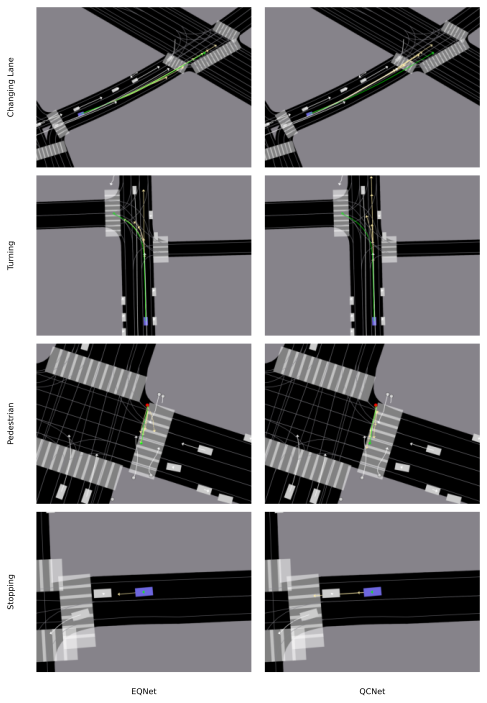

In [8]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

# Get a list of all SVG files
svg_files = [
    "results/PLOTS/EQNet-Viz/103f124f-7a2a-43f9-9f2c-5e094fc3eea8.png",
    "results/PLOTS/QCNet-Viz/103f124f-7a2a-43f9-9f2c-5e094fc3eea8.png",
    "results/PLOTS/EQNet-Viz/17d60510-4ae9-48f4-be00-0ed3d35dbfe1.png",
    "results/PLOTS/QCNet-Viz/17d60510-4ae9-48f4-be00-0ed3d35dbfe1.png",
    "results/PLOTS/EQNet-Viz/12a08897-cf80-4469-9e7e-7851ff85cc60.png", # ped
    "results/PLOTS/QCNet-Viz/12a08897-cf80-4469-9e7e-7851ff85cc60.png", # ped
    # "results/PLOTS/EQNet-Viz/1aadf2cd-6e8e-43f5-aac9-eda904b5b65f.png", # ped
    # "results/PLOTS/QCNet-Viz/1aadf2cd-6e8e-43f5-aac9-eda904b5b65f.png", # ped
    "results/PLOTS/EQNet-Viz/147a4dc7-00f0-4cce-88ad-b720214814a8.png", # stopping
    "results/PLOTS/QCNet-Viz/147a4dc7-00f0-4cce-88ad-b720214814a8.png", # stopping
]

# Set the number of rows and columns in the grid
num_rows = len(svg_files) // 2
num_cols = 2

# Labels
row_labels = [
    "Changing Lane",
    "Turning",
    "Pedestrian",
    "Stopping",
]
col_labels = [
    "EQNet", 
    "QCNet",
]

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 3*num_rows))
axes = axes.flatten()
# Iterate through the SVG files and plot them on the grid
for i, svg_path in enumerate(svg_files):
    row = i // num_cols
    col = i % num_cols
    img = plt.imread(svg_path, format='svg')
    axes[i].imshow(img)
    axes[i].axis('off')
    if col == 0:
        axes[i].text(-0.1, 0.5, row_labels[row], va='center', ha='right', rotation=90, transform=axes[i].transAxes, fontsize=8)
    if row == num_rows - 1:
        axes[i].text(0.5, -0.1, col_labels[col], va='top', ha='center', transform=axes[i].transAxes, fontsize=8)

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Show the plot
plt.show()

fig.savefig(f"results/PLOTS/eqnet_vs_qcnet_viz.png", bbox_inches='tight', pad_inches=0, dpi=400)